<a href="https://colab.research.google.com/github/spandana9318/Scikit_learn/blob/main/RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data')

In [ ]:
df

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
col_names = ['buying', 'maint', 'doors','persons','lug_boot','safety', 'class' ]

In [ ]:
df.columns = col_names

In [ ]:
df

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   object
 3   persons   1727 non-null   object
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [ ]:
df.describe(include='all').T

,count,unique,top,freq
buying,1727,4,high,432
maint,1727,4,high,432
doors,1727,4,3,432
persons,1727,3,4,576
lug_boot,1727,3,med,576
safety,1727,3,med,576
class,1727,4,unacc,1209


In [ ]:
for col in col_names:
  print(df[col].value_counts())

buying
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
maint
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
doors
3        432
4        432
5more    432
2        431
Name: count, dtype: int64
persons
4       576
more    576
2       575
Name: count, dtype: int64
lug_boot
med      576
big      576
small    575
Name: count, dtype: int64
safety
med     576
high    576
low     575
Name: count, dtype: int64
class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [ ]:
df[df.duplicated()]

,buying,maint,doors,persons,lug_boot,safety,class


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
df['buying'] = oe.fit_transform(df[['buying']])
df['maint'] = oe.fit_transform(df[['maint']])
df['doors'] = oe.fit_transform(df[['doors']])
df['persons'] = oe.fit_transform(df[['persons']])
df['lug_boot'] = oe.fit_transform(df[['lug_boot']])
df['safety'] = oe.fit_transform(df[['safety']])
df['class'] = oe.fit_transform(df[['class']])

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   buying    1727 non-null   float64
 1   maint     1727 non-null   float64
 2   doors     1727 non-null   float64
 3   persons   1727 non-null   float64
 4   lug_boot  1727 non-null   float64
 5   safety    1727 non-null   float64
 6   class     1727 non-null   float64
dtypes: float64(7)
memory usage: 94.6 KB


In [ ]:
X = df.iloc[:, 0:-1]
y = df.iloc[:,-1]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y , random_state=0, test_size=0.30)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc1 = RandomForestClassifier()
rfc1.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
pred1 = rfc1.predict(X_test)

In [ ]:
pred1

array([0., 2., 2., 2., 2., 0., 2., 2., 0., 0., 2., 2., 0., 2., 0., 0., 2.,
       2., 0., 2., 2., 2., 3., 2., 2., 2., 0., 2., 2., 2., 2., 2., 2., 2.,
       1., 0., 2., 2., 2., 2., 0., 2., 0., 2., 2., 2., 0., 0., 2., 0., 0.,
       0., 2., 2., 2., 2., 2., 2., 2., 0., 2., 2., 2., 2., 0., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 0., 3., 2., 0., 2., 2., 0., 0., 0., 2., 0.,
       0., 2., 3., 2., 2., 2., 2., 2., 2., 2., 3., 0., 3., 2., 2., 2., 2.,
       2., 2., 3., 0., 2., 2., 0., 2., 2., 2., 2., 3., 2., 0., 2., 2., 2.,
       2., 2., 0., 2., 2., 2., 2., 2., 2., 1., 2., 2., 2., 3., 2., 2., 2.,
       2., 0., 0., 2., 2., 2., 2., 2., 2., 2., 2., 0., 2., 0., 3., 0., 0.,
       2., 2., 2., 2., 2., 2., 2., 0., 2., 2., 1., 2., 2., 0., 2., 2., 0.,
       2., 2., 2., 2., 3., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 3., 2., 0., 2., 0., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 0., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2.

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(pred1, y_test)

0.9633911368015414

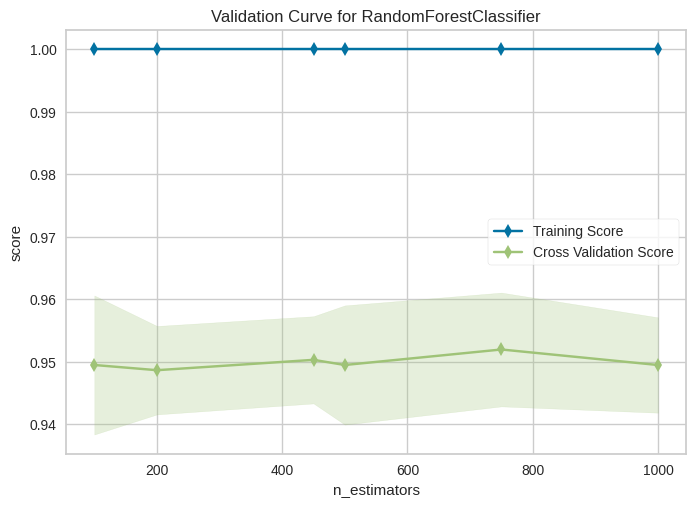

ValidationCurve(ax=<Axes: title={'center': 'Validation Curve for RandomForestClassifier'}, xlabel='n_estimators', ylabel='score'>,
                cv=3, estimator=RandomForestClassifier(),
                param_name='n_estimators',
                param_range=array([ 100,  200,  450,  500,  750, 1000]),
                scoring='accuracy')


In [ ]:
from yellowbrick.model_selection import validation_curve
num_est = [100, 200, 450, 500, 750, 1000]
print(validation_curve(RandomForestClassifier(), X= X_train, y= y_train, param_name='n_estimators', param_range=num_est, scoring='accuracy', cv=3))

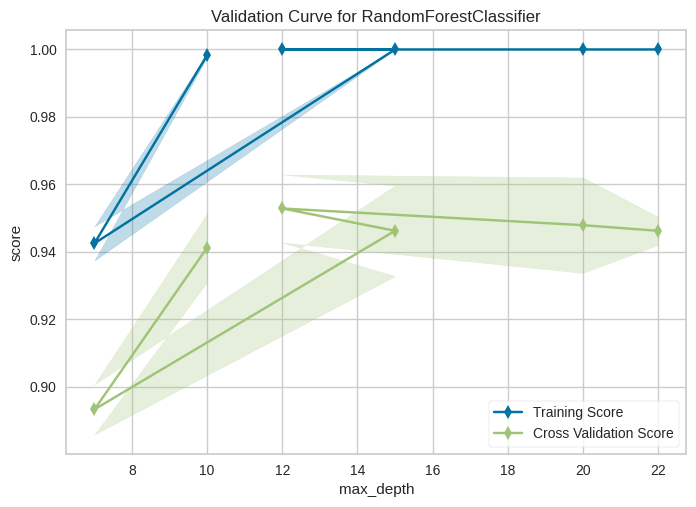

ValidationCurve(ax=<Axes: title={'center': 'Validation Curve for RandomForestClassifier'}, xlabel='max_depth', ylabel='score'>,
                cv=3, estimator=RandomForestClassifier(),
                param_name='max_depth',
                param_range=array([10,  7, 15, 12, 20, 22]),
                scoring='accuracy')


In [ ]:
from yellowbrick.model_selection import validation_curve
depth_vals = [10, 7, 15, 12, 20, 22]
print(validation_curve(RandomForestClassifier(), X= X_train, y= y_train, param_name='max_depth', param_range=depth_vals, scoring='accuracy', cv=3))

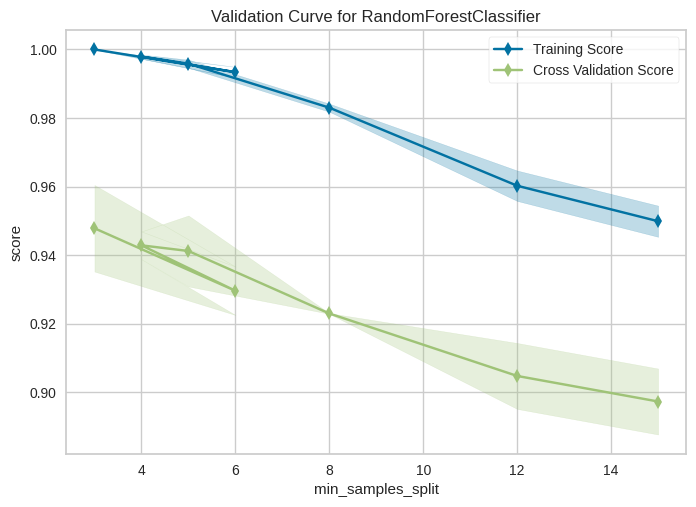

ValidationCurve(ax=<Axes: title={'center': 'Validation Curve for RandomForestClassifier'}, xlabel='min_samples_split', ylabel='score'>,
                cv=3, estimator=RandomForestClassifier(),
                param_name='min_samples_split',
                param_range=array([ 3,  6,  4,  5,  8, 12, 15]),
                scoring='accuracy')


In [ ]:
min_samples = [3, 6, 4, 5, 8, 12, 15]
print(validation_curve(RandomForestClassifier(), X= X_train, y= y_train, param_name='min_samples_split', param_range=min_samples, scoring='accuracy', cv=3))

In [ ]:
clf2 = RandomForestClassifier(n_estimators=1000, min_samples_split=3, max_depth=15, random_state=0)
clf2.fit(X_train, y_train)
pred2 = clf2.predict(X_test)
accuracy_score(pred2, y_test)


0.9653179190751445

In [ ]:
feature_scores = pd.Series(clf2.feature_importances_,index=X_train.columns).sort_values(ascending=False)

In [ ]:
print(feature_scores)

safety      0.285888
persons     0.236649
buying      0.173383
maint       0.149737
lug_boot    0.086017
doors       0.068326
dtype: float64


Text(0.5, 0, 'Feature important scores')

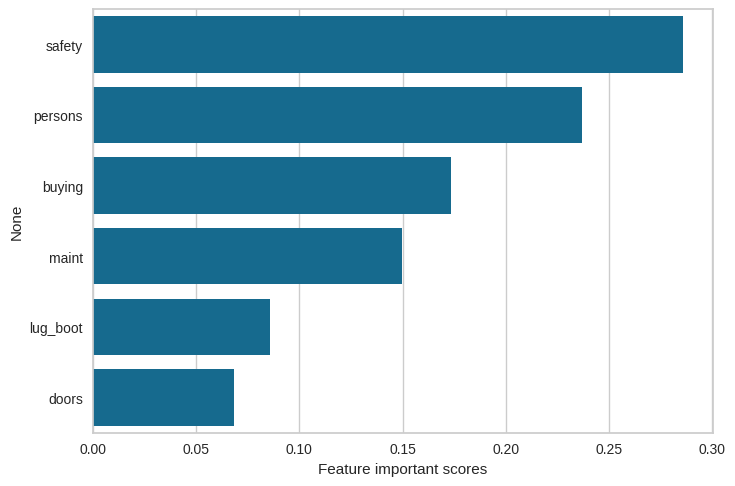

In [ ]:
sns.barplot(x=feature_scores, y=feature_scores.index)
plt.xlabel('Feature important scores')

In [ ]:
clf3= RandomForestClassifier()

Xn = df.drop(['doors', 'lug_boot', 'maint'], axis = 1)
yn = df['class']

X_trainn, X_testn, y_trainn, y_testn =  train_test_split(Xn,yn, random_state=0, test_size=0.30)
clf3.fit(X_trainn, y_trainn)
new_pred = clf3.predict(X_testn)

In [ ]:
accuracy_score(new_pred, y_test)

1.0